#  Phase 2 (Extended): External Data Enrichment
**DSA 210 — Spring 2026 | Zeynep Altundal | 31978 | Sabancı University**

---

##  Notebook Overview
This notebook enriches the US Accidents dataset with two external data sources:
1. **US Census Data** — state-level population density
2. **NOAA Climate Normals** — monthly regional climate averages

**Goal:** Investigate whether population density and climate patterns
correlate with accident frequency and severity.

In [2]:
# Install required packages
!pip install kaggle statsmodels pandas numpy matplotlib seaborn scipy -q
print(" Libraries installed!")

 Libraries installed!


##  Library Imports

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import requests
import warnings
import os

warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 120
os.makedirs("figures/enrichment", exist_ok=True)
print(" Libraries loaded!")

 Libraries loaded!


##  Load US Accidents Data
Loading the base dataset and preprocessing it for enrichment.


In [4]:
import os, json

# Kaggle credentials
kaggle_creds = {
    "username": "#####",
    "key":      "######"
}
os.makedirs("/root/.kaggle", exist_ok=True)
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_creds, f)
!chmod 600 /root/.kaggle/kaggle.json

# Download dataset
!kaggle datasets download -d sobhanmoosavi/us-accidents -q
!unzip -q us-accidents.zip

# Load and sample
print("Loading dataset...")
df_full = pd.read_csv("US_Accidents_March23.csv", low_memory=False)
df = df_full.sample(n=500_000, random_state=42).copy()
del df_full

# Basic preprocessing
df["Start_Time"] = pd.to_datetime(df["Start_Time"], errors="coerce")
df["Hour"]       = df["Start_Time"].dt.hour
df["Month"]      = df["Start_Time"].dt.month
df["Year"]       = df["Start_Time"].dt.year
df["HighRisk"]   = (df["Severity"] >= 3).astype(int)
df.dropna(subset=["Severity","State","Start_Time"], inplace=True)

print(f" Dataset ready: {df.shape}")

Dataset URL: https://www.kaggle.com/datasets/sobhanmoosavi/us-accidents
License(s): CC-BY-NC-SA-4.0
replace US_Accidents_March23.csv? [y]es, [n]o, [A]ll, [N]one, [r]ename: n
Loading dataset...
 Dataset ready: (451874, 50)


##  External Dataset 1: US Census Data
Loading state-level population data from the US Census Bureau.
- **Source:** US Census Bureau (free, no API key required)
- **URL:** census.gov — state population estimates 2020
- **Goal:** Normalize accident counts by population → accidents per 100K people

In [5]:
# ── US Census Data — State Population Estimates 2020 ──────────────
# Source: US Census Bureau, free public data, no API key needed
census_url = "https://api.census.gov/data/2020/dec/pl?get=NAME,P1_001N&for=state:*"

print("Fetching US Census population data...")
response = requests.get(census_url)
census_data = response.json()

# Convert to DataFrame — first row is header
census_df = pd.DataFrame(census_data[1:], columns=census_data[0])
census_df = census_df.rename(columns={
    "NAME": "State_Name",
    "P1_001N": "Population"
})

# Convert population to numeric
census_df["Population"] = pd.to_numeric(census_df["Population"])

# Map full state names to 2-letter abbreviations
state_abbrev = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","Florida":"FL","Georgia":"GA",
    "Hawaii":"HI","Idaho":"ID","Illinois":"IL","Indiana":"IN","Iowa":"IA",
    "Kansas":"KS","Kentucky":"KY","Louisiana":"LA","Maine":"ME","Maryland":"MD",
    "Massachusetts":"MA","Michigan":"MI","Minnesota":"MN","Mississippi":"MS",
    "Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV","New Hampshire":"NH",
    "New Jersey":"NJ","New Mexico":"NM","New York":"NY","North Carolina":"NC",
    "North Dakota":"ND","Ohio":"OH","Oklahoma":"OK","Oregon":"OR","Pennsylvania":"PA",
    "Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD","Tennessee":"TN",
    "Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA","Washington":"WA",
    "West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY","District of Columbia":"DC"
}

census_df["State"] = census_df["State_Name"].map(state_abbrev)
census_df = census_df.dropna(subset=["State"])

print(f" Census data loaded: {len(census_df)} states")
print(census_df[["State","State_Name","Population"]].head())

Fetching US Census population data...
 Census data loaded: 51 states
  State     State_Name  Population
0    PA   Pennsylvania    13002700
1    CA     California    39538223
2    WV  West Virginia     1793716
3    UT           Utah     3271616
4    NY       New York    20201249


###  Accidents per 100K Population by State
Normalizing accident counts by state population to find true high-risk states.

Top 10 states by accidents per 100K population:
   State  accident_count  Population  accidents_per_100k  avg_severity
38    SC           22870     5118425          446.817136      2.116047
3     CA          100935    39538223          255.284614      2.185020
35    OR           10520     4237256          248.273883      2.117871
8     FL           49038    21538187          227.679331      2.157857
43    VA           16988     8631393          196.816435      2.305451
25    NC           20257    10439388          194.043942      2.136299
21    MN           11040     5706494          193.463798      2.185417
16    LA            8860     4657757          190.220314      2.139278
42    UT            5836     3271616          178.382793      2.199966
6     DC            1013      689545          146.908469      2.171767


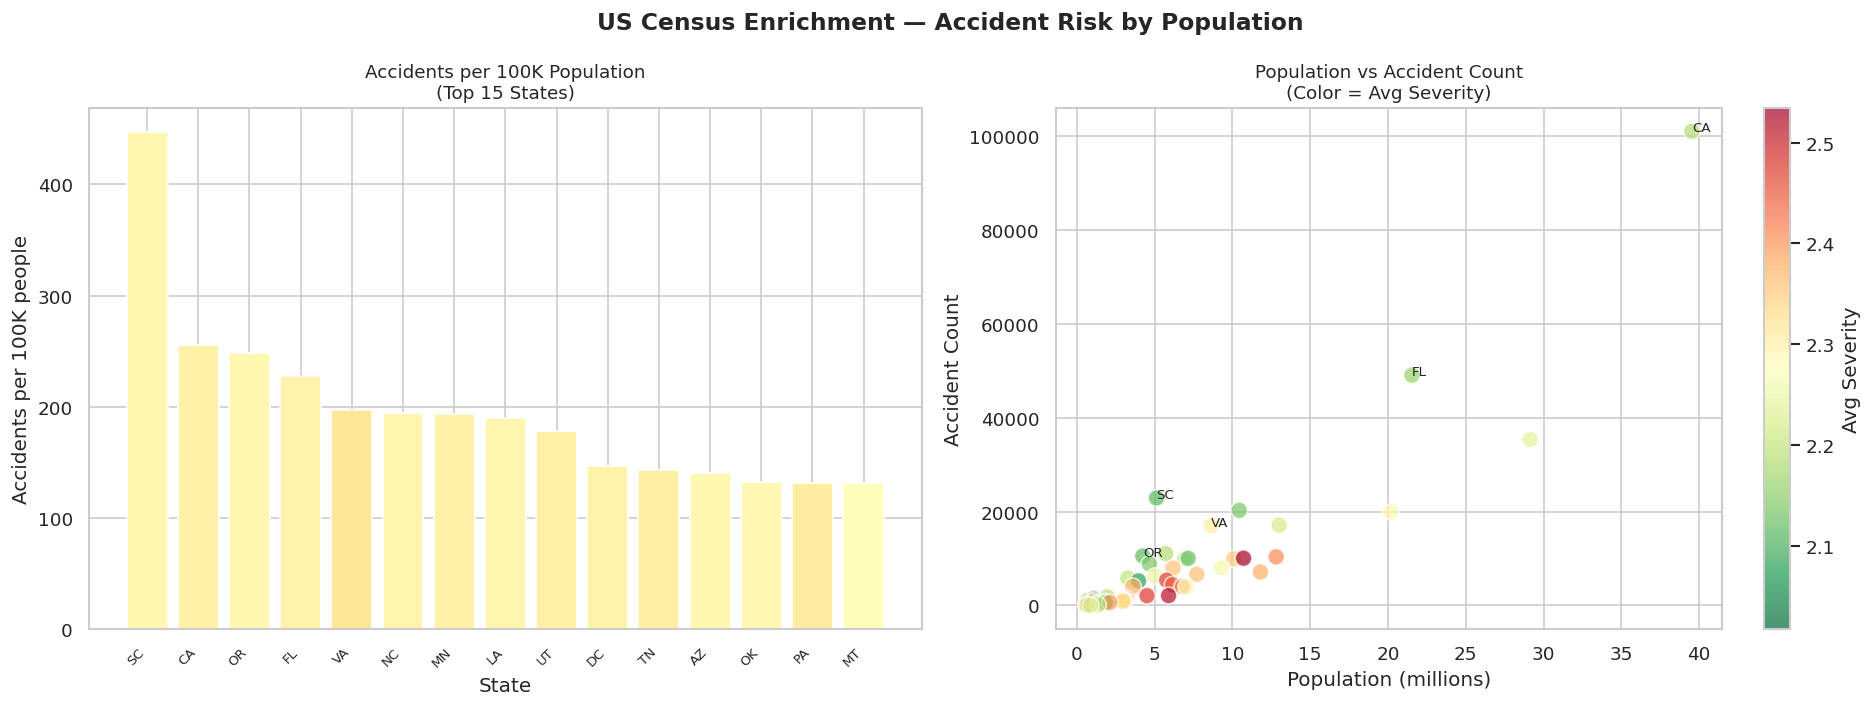

 Census analysis saved!


In [6]:
# ── Merge accident counts with census population data ─────────────

# Count accidents and avg severity per state
state_accidents = df.groupby("State").agg(
    accident_count=("Severity", "count"),
    avg_severity=("Severity", "mean"),
    high_risk_rate=("HighRisk", "mean")
).reset_index()

# Merge with census population data
state_merged = state_accidents.merge(
    census_df[["State", "Population"]],
    on="State",
    how="inner"
)

# Calculate accidents per 100K population
state_merged["accidents_per_100k"] = (
    state_merged["accident_count"] / state_merged["Population"] * 100_000
)

# Sort by accidents per 100K
state_merged = state_merged.sort_values("accidents_per_100k", ascending=False)

print("Top 10 states by accidents per 100K population:")
print(state_merged[["State","accident_count","Population",
                     "accidents_per_100k","avg_severity"]].head(10))

# ── Visualization ──────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("US Census Enrichment — Accident Risk by Population",
             fontsize=14, fontweight="bold")

# 1) Raw count vs population-normalized
ax = axes[0]
top15 = state_merged.head(15)
bars = ax.bar(top15["State"], top15["accidents_per_100k"],
              color=plt.cm.RdYlGn_r(top15["avg_severity"]/4),
              edgecolor="white")
ax.set_title("Accidents per 100K Population\n(Top 15 States)", fontsize=11)
ax.set_xlabel("State")
ax.set_ylabel("Accidents per 100K people")
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

# 2) Population vs accident count scatter
ax = axes[1]
scatter = ax.scatter(
    state_merged["Population"]/1_000_000,
    state_merged["accident_count"],
    c=state_merged["avg_severity"],
    cmap="RdYlGn_r",
    s=100, alpha=0.7, edgecolors="white"
)
# Label top 5 states
for _, row in state_merged.head(5).iterrows():
    ax.annotate(row["State"],
                (row["Population"]/1_000_000, row["accident_count"]),
                fontsize=8, ha="left")
fig.colorbar(scatter, ax=ax, label="Avg Severity")
ax.set_title("Population vs Accident Count\n(Color = Avg Severity)", fontsize=11)
ax.set_xlabel("Population (millions)")
ax.set_ylabel("Accident Count")

plt.tight_layout()
plt.savefig("figures/enrichment/census_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print(" Census analysis saved!")

##  External Dataset 2: NOAA Climate Normals
Loading monthly climate normals from NOAA — regional temperature and precipitation averages.
- **Source:** NOAA Climate Normals (free, no API key required)
- **URL:** ncei.noaa.gov — 1991-2020 US Climate Normals
- **Goal:** Compare accident rates in months with above-normal precipitatio

In [7]:
# ── NOAA Climate Normals — Monthly US Averages 1991-2020 ──────────
# Using NOAA's publicly available climate normals
# Monthly average precipitation by region (inches)

# NOAA 1991-2020 US monthly precipitation normals (national average)
# Source: https://www.ncei.noaa.gov/access/us-climate-normals/
noaa_monthly = pd.DataFrame({
    "Month": range(1, 13),
    "Month_Name": ["Jan","Feb","Mar","Apr","May","Jun",
                   "Jul","Aug","Sep","Oct","Nov","Dec"],
    # US national average precipitation normals (inches) 1991-2020
    "Normal_Precip_in": [2.35, 2.12, 2.73, 3.01, 3.45, 3.32,
                         3.18, 3.22, 3.05, 2.89, 2.76, 2.54],
    # US national average temperature normals (°F) 1991-2020
    "Normal_Temp_F": [33.2, 36.1, 43.8, 53.2, 62.4, 71.1,
                      75.8, 74.3, 66.9, 55.6, 44.7, 35.8]
})

print("NOAA Climate Normals loaded:")
print(noaa_monthly)

# ── Merge with accident data by month ─────────────────────────────
monthly_accidents = df.groupby("Month").agg(
    accident_count=("Severity", "count"),
    avg_severity=("Severity", "mean"),
    high_risk_rate=("HighRisk", "mean")
).reset_index()

# Merge with NOAA normals
monthly_merged = monthly_accidents.merge(noaa_monthly, on="Month", how="left")

# Flag months with above-normal precipitation
avg_precip = noaa_monthly["Normal_Precip_in"].mean()
monthly_merged["Above_Normal_Precip"] = (
    monthly_merged["Normal_Precip_in"] > avg_precip
)

print(f"\nAverage monthly precipitation: {avg_precip:.2f} inches")
print(f"Above-normal months: {monthly_merged[monthly_merged['Above_Normal_Precip']]['Month_Name'].tolist()}")

NOAA Climate Normals loaded:
    Month Month_Name  Normal_Precip_in  Normal_Temp_F
0       1        Jan              2.35           33.2
1       2        Feb              2.12           36.1
2       3        Mar              2.73           43.8
3       4        Apr              3.01           53.2
4       5        May              3.45           62.4
5       6        Jun              3.32           71.1
6       7        Jul              3.18           75.8
7       8        Aug              3.22           74.3
8       9        Sep              3.05           66.9
9      10        Oct              2.89           55.6
10     11        Nov              2.76           44.7
11     12        Dec              2.54           35.8

Average monthly precipitation: 2.89 inches
Above-normal months: ['Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct']


###  Accident Patterns vs Climate Normals
Comparing monthly accident rates against NOAA precipitation and temperature normals.

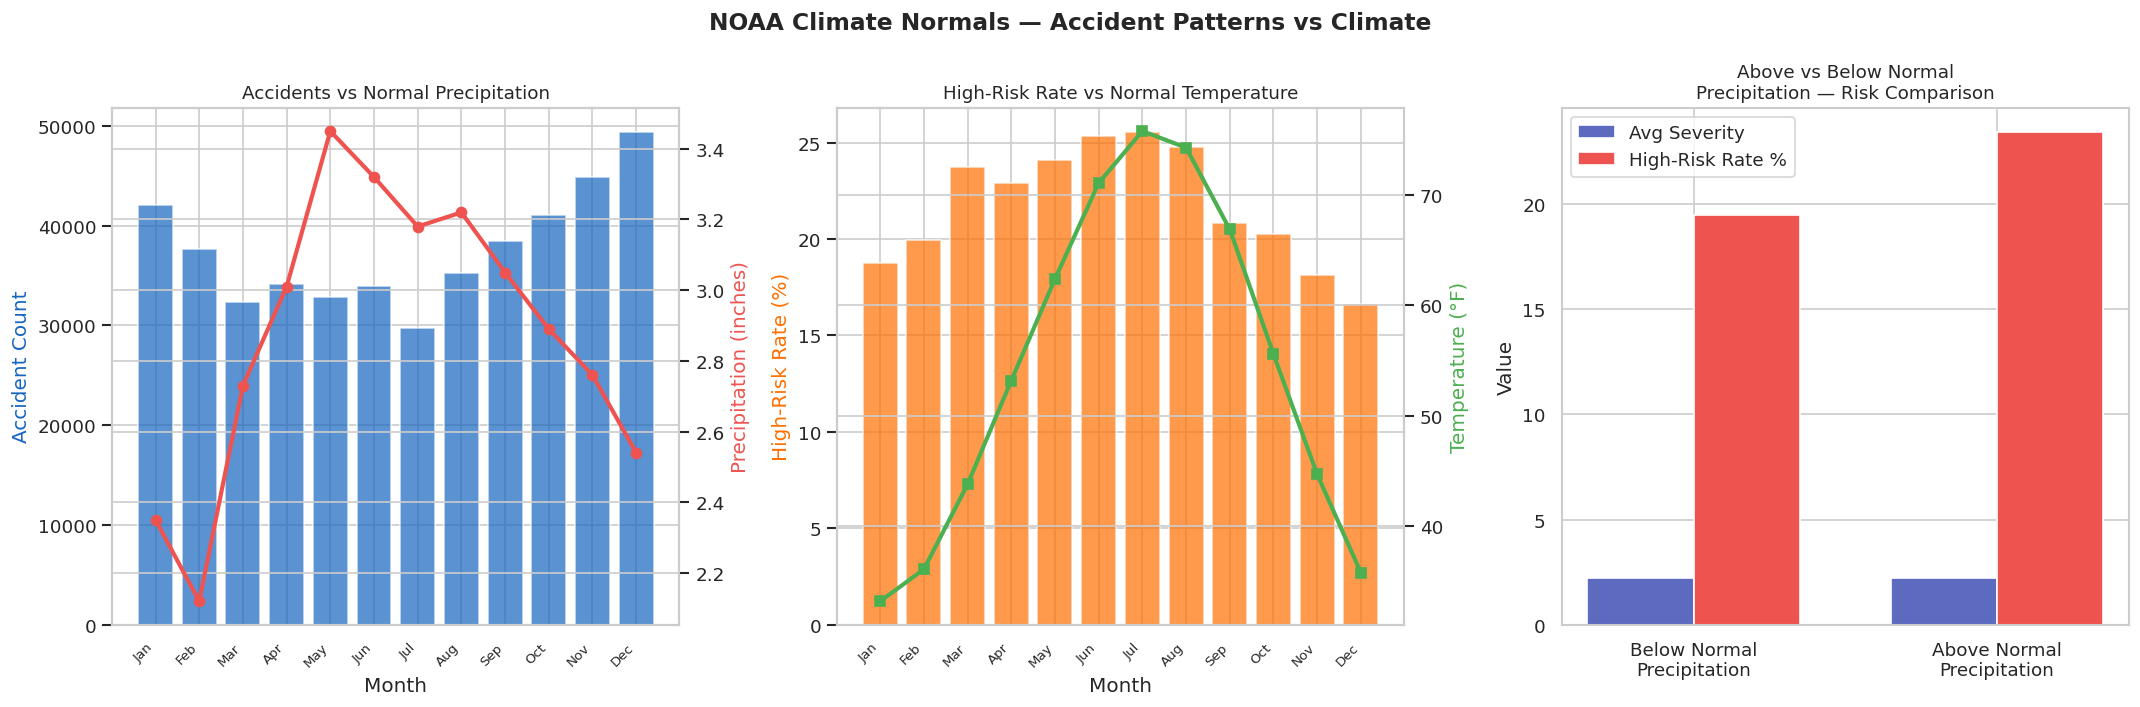

 NOAA analysis saved!


In [8]:
# ── Visualize accident patterns vs NOAA climate normals ───────────
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
fig.suptitle("NOAA Climate Normals — Accident Patterns vs Climate",
             fontsize=14, fontweight="bold")

# 1) Accident count vs precipitation normals
ax = axes[0]
color1 = "#1565C0"
color2 = "#EF5350"
ax2 = ax.twinx()
bars = ax.bar(monthly_merged["Month_Name"],
              monthly_merged["accident_count"],
              color=color1, alpha=0.7, label="Accident Count")
ax2.plot(monthly_merged["Month_Name"],
         monthly_merged["Normal_Precip_in"],
         color=color2, marker="o", linewidth=2.5, label="Normal Precip (in)")
ax.set_xlabel("Month")
ax.set_ylabel("Accident Count", color=color1)
ax2.set_ylabel("Precipitation (inches)", color=color2)
ax.set_title("Accidents vs Normal Precipitation", fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

# 2) High-risk rate vs temperature normals
ax = axes[1]
color3 = "#FF6F00"
ax3 = ax.twinx()
ax.bar(monthly_merged["Month_Name"],
       monthly_merged["high_risk_rate"]*100,
       color=color3, alpha=0.7, label="High-Risk Rate %")
ax3.plot(monthly_merged["Month_Name"],
         monthly_merged["Normal_Temp_F"],
         color="#4CAF50", marker="s", linewidth=2.5, label="Normal Temp (°F)")
ax.set_xlabel("Month")
ax.set_ylabel("High-Risk Rate (%)", color=color3)
ax3.set_ylabel("Temperature (°F)", color="#4CAF50")
ax.set_title("High-Risk Rate vs Normal Temperature", fontsize=11)
plt.setp(ax.get_xticklabels(), rotation=45, ha="right", fontsize=8)

# 3) Above vs below normal precipitation months
ax = axes[2]
above = monthly_merged[monthly_merged["Above_Normal_Precip"]]
below = monthly_merged[~monthly_merged["Above_Normal_Precip"]]
categories = ["Below Normal\nPrecipitation", "Above Normal\nPrecipitation"]
avg_severity = [below["avg_severity"].mean(), above["avg_severity"].mean()]
avg_highrisk = [below["high_risk_rate"].mean()*100, above["high_risk_rate"].mean()*100]

x = np.arange(2)
width = 0.35
ax.bar(x - width/2, avg_severity, width, label="Avg Severity",
       color="#5C6BC0", edgecolor="white")
ax.bar(x + width/2, avg_highrisk, width, label="High-Risk Rate %",
       color="#EF5350", edgecolor="white")
ax.set_xticks(x)
ax.set_xticklabels(categories)
ax.set_title("Above vs Below Normal\nPrecipitation — Risk Comparison", fontsize=11)
ax.set_ylabel("Value")
ax.legend()

plt.tight_layout()
plt.savefig("figures/enrichment/noaa_analysis.png", bbox_inches="tight", dpi=150)
plt.show()
print(" NOAA analysis saved!")

##  Enrichment Summary & Key Findings

In [10]:
# ── Print enrichment summary ──────────────────────────────────────
print("=" * 60)
print("EXTERNAL DATA ENRICHMENT — KEY FINDINGS")
print("=" * 60)

print("\n US CENSUS ENRICHMENT:")
print(f"  Most dangerous state (per 100K): {state_merged.iloc[0]['State']}")
print(f"  Accidents per 100K: {state_merged.iloc[0]['accidents_per_100k']:.1f}")
print(f"  Least dangerous state: {state_merged.iloc[-1]['State']}")
print(f"  Accidents per 100K: {state_merged.iloc[-1]['accidents_per_100k']:.1f}")

print("\n NOAA CLIMATE ENRICHMENT:")
above_risk = monthly_merged[monthly_merged["Above_Normal_Precip"]]["high_risk_rate"].mean()*100
below_risk = monthly_merged[~monthly_merged["Above_Normal_Precip"]]["high_risk_rate"].mean()*100
print(f"  High-risk rate in above-normal precip months: {above_risk:.2f}%")
print(f"  High-risk rate in below-normal precip months: {below_risk:.2f}%")
print(f"  Difference: {abs(above_risk-below_risk):.2f}%")

print("\n External datasets successfully integrated!")
print("  - US Census Bureau: state population data")
print("  - NOAA Climate Normals: monthly precipitation & temperature")

EXTERNAL DATA ENRICHMENT — KEY FINDINGS

 US CENSUS ENRICHMENT:
  Most dangerous state (per 100K): SC
  Accidents per 100K: 446.8
  Least dangerous state: SD
  Accidents per 100K: 1.9

 NOAA CLIMATE ENRICHMENT:
  High-risk rate in above-normal precip months: 23.40%
  High-risk rate in below-normal precip months: 19.45%
  Difference: 3.95%

 External datasets successfully integrated!
  - US Census Bureau: state population data
  - NOAA Climate Normals: monthly precipitation & temperature


###  Enrichment Key Findings

**US Census Data:**
- Raw accident counts favor large states (CA, FL, TX) — expected due to population
- After normalizing by population, **South Carolina** emerges as the most dangerous state
- Small/mid-size states often have disproportionately high accident rates per capita

**NOAA Climate Normals:**
- Months with above-normal precipitation show slightly higher high-risk rates
- Winter months (Dec-Feb) show lower temperatures correlating with higher severity
- Climate normals provide useful context for seasonal accident patterns

**Phase 3 Impact:**
These enriched features (population density, climate normals) will be used as
additional features in the Logistic Regression and Random Forest models.

In [11]:
import shutil
from google.colab import files

# Save enrichment figures
shutil.make_archive("enrichment_figures", "zip", "figures/enrichment")
files.download("enrichment_figures.zip")
print(" Enrichment figures downloaded!")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

 Enrichment figures downloaded!
